In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.api as sm 

In [4]:
loc = 'C:/Users/LAPTOP/Downloads/teleCust1000t.csv'
tele_data = pd.read_csv(loc)
tele_data.sample(6)

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
139,3,11,32,0,6,125.0,4,5,0.0,0,1,4
359,3,32,50,0,28,57.0,4,20,0.0,0,1,3
129,2,70,64,1,18,98.0,1,31,0.0,1,2,4
832,1,69,42,1,23,19.0,3,0,0.0,1,2,1
46,1,49,51,1,27,63.0,4,19,0.0,0,5,2
35,3,20,35,1,11,52.0,4,0,0.0,0,2,2


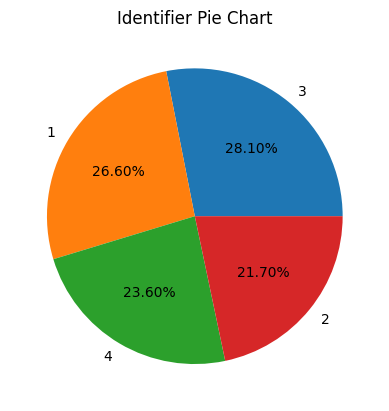

In [5]:
val = tele_data['custcat'].value_counts()
iden = val.index
size = val.values
fig, ax = plt.subplots()
ax.pie(size, labels=iden, autopct="%.2f%%")
ax.set_title("Identifier Pie Chart")
plt.show()

<Axes: >

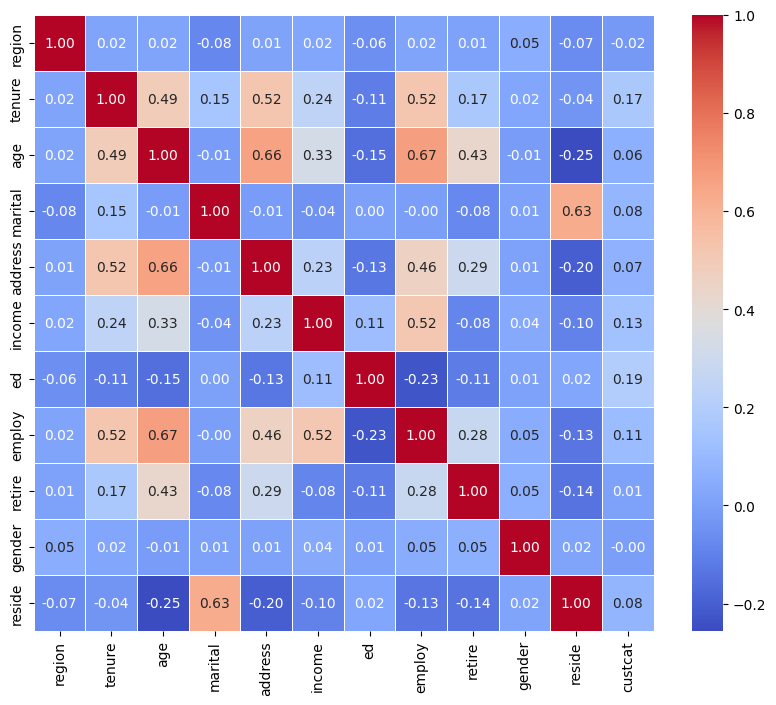

In [6]:
correlation_matrix = tele_data.corr().drop('custcat')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

In [7]:
correlation_values = abs(tele_data.corr()['custcat'].drop('custcat')).sort_values(ascending=False)
correlation_values[:6]

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
Name: custcat, dtype: float64

In [81]:
para = tele_data.drop('custcat', axis=1)
cust = tele_data['custcat']
scaler = StandardScaler()
stan = scaler.fit_transform(para)
stan = normalize(stan, norm='l1', copy=False)
model = sm.OLS(cust, para)
stats = model.fit()
print(stats.summary())
#pd.DataFrame(stan_n)

                                 OLS Regression Results                                
Dep. Variable:                custcat   R-squared (uncentered):                   0.838
Model:                            OLS   Adj. R-squared (uncentered):              0.837
Method:                 Least Squares   F-statistic:                              466.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):                        0.00
Time:                        17:18:41   Log-Likelihood:                         -1511.2
No. Observations:                1000   AIC:                                      3044.
Df Residuals:                     989   BIC:                                      3098.
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [82]:
stan_train, stan_test, cust_train, cust_test = train_test_split(stan, cust, test_size=.2, random_state=42)

In [100]:
k=44
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_model = knn_classifier.fit(stan_train,cust_train)

In [101]:
cust_pred = knn_model.predict(stan_test)

In [102]:
print("Test set Accuracy: ", accuracy_score(cust_test, cust_pred))

Test set Accuracy:  0.41


In [96]:
Ks = 100
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(stan_train,cust_train)
    cust_pred = knn_model_n.predict(stan_test)
    acc[n-1] = accuracy_score(cust_test, cust_pred)
    std_acc[n-1] = np.std(cust_pred==cust_test)/np.sqrt(cust_pred.shape[0])


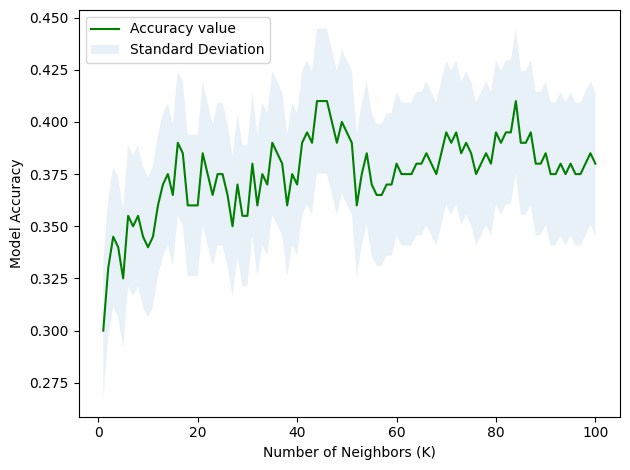

In [97]:
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [98]:
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1)

The best accuracy was with 0.41 with k = 44
